In [4]:
import numpy as np

X_features = np.load("../data/processed/ml_features_400.npy")
data = np.load("../data/processed/processed_400_timesteps.npz", allow_pickle=True)
y = data["y"]

print(X_features.shape)  # (10000, 1200)


(10000, 1200)


In [5]:
def create_mil_instances(X, segments=8):
    """
    Split feature vector into multiple instances for MIL.
    """
    instance_size = X.shape[1] // segments
    bags = []

    for i in range(X.shape[0]):
        bag = []
        for s in range(segments):
            start = s * instance_size
            end = (s + 1) * instance_size
            bag.append(X[i, start:end])
        bags.append(bag)

    return np.array(bags)


In [6]:
X_bags = create_mil_instances(X_features, segments=8)

print("MIL bags shape:", X_bags.shape)


MIL bags shape: (10000, 8, 150)


In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

inputs = Input(shape=(X_bags.shape[1], X_bags.shape[2]))

scores = Dense(1, activation="tanh")(inputs)
weights = tf.nn.softmax(scores, axis=1)
bag_repr = tf.reduce_sum(inputs * weights, axis=1)

output = Dense(len(np.unique(y)), activation="softmax")(bag_repr)

mil_model = Model(inputs, output)
mil_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mil_model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 8, 150)]     0           []                               
                                                                                                  
 dense (Dense)                  (None, 8, 1)         151         ['input_1[0][0]']                
                                                                                                  
 tf.nn.softmax (TFOpLambda)     (None, 8, 1)         0           ['dense[0][0]']                  
                                                                                                  
 tf.math.multiply (TFOpLambda)  (None, 8, 150)       0           ['input_1[0][0]',                
                                                                  'tf.nn.softmax[0][0]']      

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

mil_model.fit(
    X_bags,
    y_enc,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
250/250 [==============================] - 1s 2ms/step - loss: 0.1053 - accuracy: 0.9631 - val_loss: 1.3823 - val_accuracy: 0.7175
Epoch 2/50
250/250 [==============================] - 0s 2ms/step - loss: 0.1124 - accuracy: 0.9625 - val_loss: 1.3352 - val_accuracy: 0.7340
Epoch 3/50
250/250 [==============================] - 0s 2ms/step - loss: 0.1050 - accuracy: 0.9656 - val_loss: 1.5339 - val_accuracy: 0.6935
Epoch 4/50
250/250 [==============================] - 0s 2ms/step - loss: 0.1042 - accuracy: 0.9646 - val_loss: 1.3801 - val_accuracy: 0.7270
Epoch 5/50
250/250 [==============================] - 0s 2ms/step - loss: 0.1036 - accuracy: 0.9639 - val_loss: 1.4832 - val_accuracy: 0.7025
Epoch 6/50
250/250 [==============================] - 0s 2ms/step - loss: 0.1021 - accuracy: 0.9657 - val_loss: 1.4659 - val_accuracy: 0.7005
Epoch 7/50
250/250 [==============================] - 1s 2ms/step - loss: 0.0995 - accuracy: 0.9651 - val_loss: 1.3193 - val_accuracy: 0.7440
Epoch 

1/1 [==============================] - 0s 115ms/step


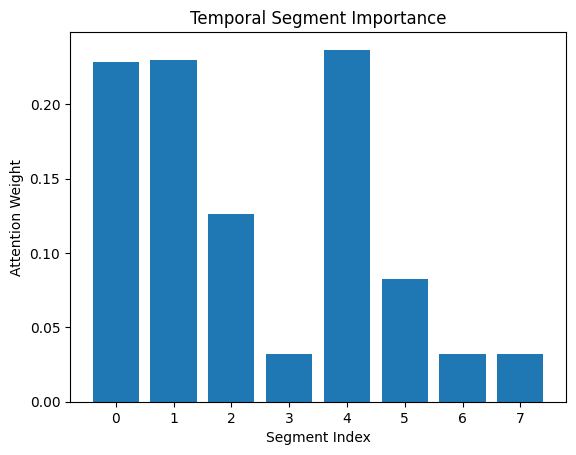

In [11]:
att_model = Model(inputs, weights)

sample_weights = att_model.predict(X_bags[:1])[0].squeeze()

import matplotlib.pyplot as plt
plt.bar(range(len(sample_weights)), sample_weights)
plt.title("Temporal Segment Importance")
plt.xlabel("Segment Index")
plt.ylabel("Attention Weight")
plt.show()


In [12]:
import os
os.makedirs("../outputs/models", exist_ok=True)


In [13]:
mil_model.save("../outputs/models/mil_attention_model")
print("MIL model saved successfully")


INFO:tensorflow:Assets written to: ../outputs/models/mil_attention_model\assets


INFO:tensorflow:Assets written to: ../outputs/models/mil_attention_model\assets


MIL model saved successfully
